# 1D Diffusion Models with Fixed Score Perturbation

This notebook compares two 1D diffusion dynamics, `OU` and `COU`, when the reverse process uses a perturbed analytic score of the form

$$\hat{s}_t(x \mid x_0) = \frac{\mu_t(x_0) - x + \varepsilon}{\sigma_t^2}.$$

The experiment starts from a single point `x_0 = -2`, samples `x_T` from the forward process, runs the reverse sampler, and evaluates the reconstruction quality with the 1D Wasserstein-2 distance as `T` varies.


## 1. Setup

The notebook keeps the original experiment design, but organizes the implementation into reusable helpers for model dynamics, diagnostics, sampling, evaluation, and plotting.


In [66]:
# Uncomment in a fresh environment.
# %pip install torch POT

import numpy as np
import matplotlib.pyplot as plt
import torch
import ot
from matplotlib.ticker import MaxNLocator


In [67]:
DTYPE = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tilde_T = 20
methods_plot = ['OU', 'COU']
T_plot = np.arange(1, tilde_T + 0.5, 0.5)
sample_size = 20_000
x_0 = torch.tensor(-1.0, dtype=DTYPE, device=device)
reconstruction_clip = (-2.0, 0.0)

experiment_grid = [
    {'noise_lvl': 1.0, 'time_step': 0.02},
    {'noise_lvl': 0.5, 'time_step': 0.02},
    {'noise_lvl': 0.05, 'time_step': 0.05},
    {'noise_lvl': 0.02, 'time_step': 0.05},
]

base_constants = {
    'mu': torch.tensor(0.0, dtype=DTYPE, device=device),
    'theta': torch.tensor(1.0, dtype=DTYPE, device=device),
    'sigma': torch.tensor(1.0, dtype=DTYPE, device=device),
}

device


device(type='cpu')

## 2. How to Read the Experiment

A few implementation choices matter when interpreting the plots.

- `T` is the terminal diffusion time, or diffusion horizon. Each x-axis value means: diffuse from `x_0` to time `T`, then reverse from that same time `T`.
- In standard Gaussian notation, `\mu_t` is the forward mean, `\sigma_t` is the forward standard deviation, and `\sigma_t^2` is the forward variance.
- The notebook intentionally perturbs the numerator before dividing by the variance. In score space this behaves like an additive bias of `epsilon / sigma_t^2`, not a constant additive error independent of time.
- Because `COU` has a much larger forward variance than `OU` for the same `T`, the same numerator perturbation produces a smaller effective score bias for `COU`.
- The `sigma_t` inside the reverse Euler update is the SDE diffusion coefficient, so the reverse drift correction uses `sigma_t ** 2 * score`. This is separate from the Gaussian marginal denominator `sigma_t^2` in the score formula.
- `reconstruction_clip` is applied before computing `W_2`, so the metric is measured on the clipped reverse samples.
- `backward_sample` keeps the original step rule `int(T // dt) - 1`, so the reverse chain stops near zero but not exactly at `t = 0`. This is preserved to match the original experiment.


## 3. SDE Classes

A single `SDE` class takes `name` (`'OU'` or `'COU'`) and sets an internal sign `s ∈ {-1, +1}` that determines the dynamics:

| | `s` | `mean_t` | `variance_t` | `reverse_drift` |
|---|---|---|---|---|
| OU | −1 | `mu + (x_0−mu) exp(−θt)` | `σ²/2θ · (1 − exp(−2θt))` | `θ(x−mu)` |
| COU | +1 | `mu + (x_0−mu) exp(+θt)` | `σ²/2θ · (exp(2θt) − 1)` | `−θ(x−mu)` |

`FixedNumeratorPerturbation` and `BackwardProcess` are shared helpers used by both variants.

In [68]:
_SDE_EXP_SIGN = {'OU': -1, 'COU': 1}


def as_tensor(value):
    return torch.as_tensor(value, dtype=DTYPE, device=device)


def as_float(value):
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu().item())
    return float(value)


def config_label(config):
    return f"noise = {config['noise_lvl']}, dt = {config['time_step']}"


class SDE:
    """OU or COU SDE, selected by name.

    Sign s = _SDE_EXP_SIGN[name] unifies the two dynamics:
      mean_t        = mu + (x_0 - mu) * exp(s * theta * t)
      variance_t    = (sigma^2 / 2*theta) * s * (exp(2*s*theta*t) - 1)
      reverse_drift = -s * theta * (x - mu)
    """

    def __init__(self, name, mu, theta, sigma):
        if name not in _SDE_EXP_SIGN:
            raise ValueError(f"Unknown SDE name {name!r}. Choose from {list(_SDE_EXP_SIGN)}.")
        self.name = name
        self.mu = as_tensor(mu)
        self.theta = as_tensor(theta)
        self.sigma = as_tensor(sigma)
        self._s = _SDE_EXP_SIGN[name]

    def mean_t(self, t, x_0):
        t, x_0 = as_tensor(t), as_tensor(x_0)
        return self.mu + (x_0 - self.mu) * torch.exp(self._s * self.theta * t)

    def variance_t(self, t):
        t = as_tensor(t)
        return (self.sigma ** 2 / (2 * self.theta)) * self._s * (torch.exp(2 * self._s * self.theta * t) - 1)

    def std_t(self, t):
        return torch.sqrt(self.variance_t(t))

    def true_score(self, t, x, x_0):
        t, x_0 = as_tensor(t), as_tensor(x_0)
        return (self.mean_t(t, x_0) - x) / self.variance_t(t)

    def diffusion_coefficient(self, t=None, x=None):
        return self.sigma

    def reverse_drift(self, x, t):
        return -self._s * self.theta * (x - self.mu)

    def forward_sample(self, x_0, t, sample_size):
        t, x_0 = as_tensor(t), as_tensor(x_0)
        noise = torch.randn(sample_size, dtype=DTYPE, device=device)
        return self.mean_t(t, x_0) + self.std_t(t) * noise


class FixedNumeratorPerturbation:
    def __init__(self, sde, noise_lvl):
        self.sde = sde
        self.noise_lvl = as_tensor(noise_lvl)

    def perturbed_score(self, t, x, x_0):
        t, x_0 = as_tensor(t), as_tensor(x_0)
        return (self.sde.mean_t(t, x_0) - x + self.noise_lvl) / self.sde.variance_t(t)


class BackwardProcess:
    def __init__(self, sde, score_process):
        self.sde = sde
        self.score_process = score_process

    @staticmethod
    def step_count(T, time_step):
        return max(int(T // time_step) - 1, 0)

    @classmethod
    def terminal_time(cls, T, time_step):
        num_steps = cls.step_count(T, time_step)
        return as_float(as_tensor(T) - num_steps * as_tensor(time_step))

    def sample(self, x_T, T, x_0, time_step):
        num_steps = self.step_count(T, time_step)
        dt = as_tensor(time_step)
        t = as_tensor(T)
        x_t_backward = x_T.clone()

        for _ in range(num_steps):
            sigma_t = self.sde.diffusion_coefficient(t=t, x=x_t_backward)
            score_noised = self.score_process.perturbed_score(t, x_t_backward, x_0)
            drift_t = self.sde.reverse_drift(x_t_backward, t)
            noise = torch.randn_like(x_t_backward)
            x_t_backward = x_t_backward + (drift_t + sigma_t ** 2 * score_noised) * dt
            x_t_backward = x_t_backward + sigma_t * torch.sqrt(dt) * noise
            t = t - dt

        return x_t_backward

In [69]:
def build_sde_registry(constants=None):
    constants = base_constants if constants is None else constants
    return {
        name: SDE(name, constants['mu'], constants['theta'], constants['sigma'])
        for name in _SDE_EXP_SIGN
    }


SDE_REGISTRY = build_sde_registry()


def build_experiment_processes(noise_lvl, sde_registry=None):
    sde_registry = SDE_REGISTRY if sde_registry is None else sde_registry
    perturbed_processes = {
        name: FixedNumeratorPerturbation(sde, noise_lvl)
        for name, sde in sde_registry.items()
    }
    backward_processes = {
        name: BackwardProcess(sde_registry[name], perturbed_processes[name])
        for name in sde_registry
    }
    return {
        'sdes': sde_registry,
        'perturbed': perturbed_processes,
        'backward': backward_processes,
    }

## 4. Sampling, Evaluation, and Plotting Utilities

In [70]:
def reverse_terminal_time(T, time_step):
    return BackwardProcess.terminal_time(T, time_step)


def wasserstein_distance_to_point(samples, target):
    target_value = float(as_tensor(target).item())
    target_array = np.full(samples.numel(), target_value)
    sample_array = samples.detach().cpu().numpy()
    return np.sqrt(ot.emd2_1d(target_array, sample_array))


def run_experiment(T_values, methods, x_0, sample_size, time_step, experiment_processes, clamp_bounds=None):
    results = {}

    for method in methods:
        sde = experiment_processes['sdes'][method]
        backward_process = experiment_processes['backward'][method]
        distances = []

        for T in T_values:
            x_T = sde.forward_sample(x_0, T, sample_size)
            x_recovered = backward_process.sample(x_T, T, x_0, time_step)

            if clamp_bounds is not None:
                x_recovered = torch.clamp(x_recovered, min=clamp_bounds[0], max=clamp_bounds[1])

            distances.append(wasserstein_distance_to_point(x_recovered, x_0))

        results[method] = distances

    return results


def run_experiment_grid(experiment_grid, T_values, methods, x_0, sample_size, clamp_bounds=None):
    experiments = []
    for config in experiment_grid:
        experiment_processes = build_experiment_processes(config['noise_lvl'])
        results = run_experiment(
            T_values=T_values,
            methods=methods,
            x_0=x_0,
            sample_size=sample_size,
            time_step=config['time_step'],
            experiment_processes=experiment_processes,
            clamp_bounds=clamp_bounds,
        )
        experiments.append({
            **config,
            'label': config_label(config),
            'reverse_terminal_time_at_max_T': reverse_terminal_time(np.max(T_values), config['time_step']),
            'results': results,
        })
    return experiments


def plot_w2_curves(ax, T_values, results, title):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(0, tilde_T)
    ax.set_title(title)
    ax.set_xlabel('Terminal time T')
    ax.set_ylabel('$W_2$ distance')

    for method, distances in results.items():
        ax.plot(T_values, distances, label=method)

    ax.legend()


def plot_experiment_grid(experiment_results, T_values, figure_title='$W_2$ distance under terminal time $T$'):
    figure, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, constrained_layout=True)
    for ax, experiment in zip(axes.flat, experiment_results):
        plot_w2_curves(ax, T_values, experiment['results'], experiment['label'])
    figure.suptitle(figure_title, fontsize=16)
    return figure, axes


def summarize_experiment_results(experiment_results):
    summary = []
    for experiment in experiment_results:
        row = {
            'label': experiment['label'],
            'reverse_terminal_time_at_max_T': round(float(experiment['reverse_terminal_time_at_max_T']), 6),
        }
        method_means = {}
        for method, distances in experiment['results'].items():
            distances = np.asarray(distances, dtype=float)
            method_means[method] = distances.mean()
            row[f'{method}_mean_W2'] = round(float(distances.mean()), 6)
            row[f'{method}_min_W2'] = round(float(distances.min()), 6)
            row[f'{method}_max_W2'] = round(float(distances.max()), 6)
            row[f'{method}_final_W2'] = round(float(distances[-1]), 6)
        row['better_method_by_mean_W2'] = min(method_means, key=method_means.get)
        summary.append(row)
    return summary

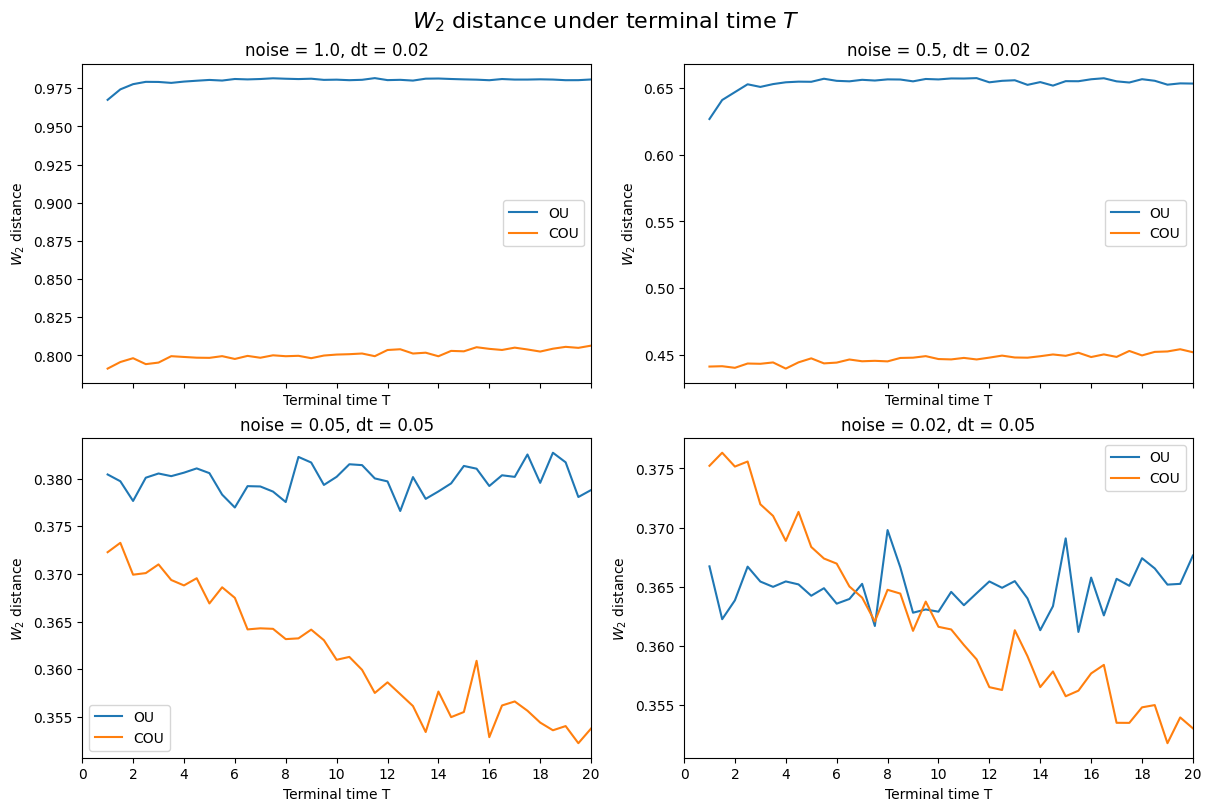

In [71]:
experiment_results = run_experiment_grid(
    experiment_grid=experiment_grid,
    T_values=T_plot,
    methods=methods_plot,
    x_0=x_0,
    sample_size=sample_size,
    clamp_bounds=reconstruction_clip,
)

figure, axes = plot_experiment_grid(experiment_results, T_plot)
figure.savefig('all_methods_w2_grid.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Run the Experiment Grid

Each subplot corresponds to one `(noise level, reverse step size)` pair from the original notebook.